# Simulation_CLP_PID_FF


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

%config InlineBackend.figure_formats ="svg"
from package_DBR import *
from package_TCLAB import *
from package_LAB import *


## Simulation parameters

In [ ]:
#Point de fonctionnement

MV0 = 50
PV0 = 54
DV0 = 50

#Parametre maniupulated value

Kp = 0.374684
T1_p = 171.145985
T2_p = 26.74464
theta_p = 12.00844


#Parmetre Disturbance Value

Kd = 0.3933681
T1_d= 161.75194
T2_d= 36.287948
theta_d= 19.570305



#IMC TUNING
gamma = 0.6
Kc,Ti,Td = IMC_Tuning(Kp, gamma, theta_p, T1_p, T1_p, 2)


alpha = 0.9
MVMin = 0
MVMax = 100
TSim = 4000
Ts = 1
N = int(TSim/Ts) + 1


print("kc = ", Kc)
print("Ti = ", Ti)
print("Td = ", Td)




kc =  4.202471166179412
Ti =  342.29197
Td =  85.5729925


# signals

In [ ]:
scenario = "CLP+noFF"



# # Scenario 1: CLP + FF
if scenario == "CLP+FF":
    ManPath = {0: True, 500: False, TSim: False} 
    MVManPath = {0: MV0+10, TSim: MV0+10} 
    SPPath = {0: PV0+5, 1500: PV0-5, TSim: PV0-5} 
    DVPath = {0: DV0, 2500: DV0+20, TSim: DV0+10}
    ActivateFF = True
    ManFF = False


## Scenario 2: CLP + no FF
if scenario == "CLP+noFF":
    ManPath = {0: True, 500: False, TSim: False} 
    MVManPath = {0: MV0, TSim: MV0} 
    SPPath = {0: PV0+5, 1500: PV0-5, TSim: PV0-5} 
    DVPath = {0: DV0, 2500: DV0+10, TSim: DV0+10}
    ActivateFF = False
    ManFF = False


# # Scenario 3: OLP + no FF
if scenario == "OLP+noFF":
    ManPath = {0: True, TSim: True}
    MVManPath = {0: MV0, TSim: MV0}
    SPPath = {0: PV0, TSim: PV0}
    DVPath = {0: 50, 1200: 60, TSim: 60}
    ActivateFF = False
    ManFF = True

## Scenario 4: OLP + FF
if scenario == "OLP+FF":
    ManPath ={0: True, TSim: True}
    MVManPath = {0: MV0, TSim: MV0}
    SPPath ={0: PV0, TSim: PV0}
    DVPath = {0: 50.0, 1200: 60, TSim: 60.0}
    ActivateFF = True
    ManFF = True



## Simulation 

In [24]:






t = []
MV = []

MVP = []
MVI = []
MVD = []

SP=[]
MVMan=[]
MVFF = []
Man =[]
ManFF = []

DV =[]
E = []
PV = []



MVFFDelay = []
MVFFLL_output = []

MVDelayp =[]
PV1p =[]
PV2p =[]

MVDelayd =[]
PV1d =[]
PV2d =[]



for i in range(0,N):

    t.append(i*Ts)
    SelectPath_RT(SPPath,t,SP)
    SelectPath_RT(DVPath,t,DV)
    

    Delay_RT(DV-DV0*np.ones_like(DV), np.max([theta_d-theta_p, 0]), Ts, MVFFDelay)
    LL_RT(MVFFDelay, -Kd/Kp, T1_p, T1_d, Ts, MVFFLL_output)

    if ActivateFF :
        LL_RT(MVFFLL_output, 1, T2_p, T2_d, Ts, MVFF)
    else :
        LL_RT(MVFFLL_output, 0, T2_p, T2_d, Ts, MVFF)

    
    SelectPath_RT(ManPath,t,Man)
    SelectPath_RT(MVManPath,t, MVMan)

    PID_RT(SP, PV, Man, MVMan, MVFF, Kc, Ti, Td, alpha , Ts, MVMin, MVMax, MV, MVP, MVI, MVD, E, ManFF, PV0)

    
    Delay_RT(MV, theta_p, Ts, MVDelayp, MV0)
    FO_RT(MVDelayp, Kp, T1_p, Ts, PV1p,0)
    FO_RT(PV1p, 1, T2_p, Ts, PV2p, 0)



    Delay_RT(DV - DV0*np.ones_like(DV), theta_d, Ts, MVDelayd, 0)
    FO_RT(MVDelayd, Kd, T1_d, Ts, PV1d, 0)
    FO_RT(PV1d, 1, T2_d, Ts, PV2d, 0)

    PV.append(PV2p[-1] + PV2d[-1] + PV0 - Kp*MV0)



# Plot

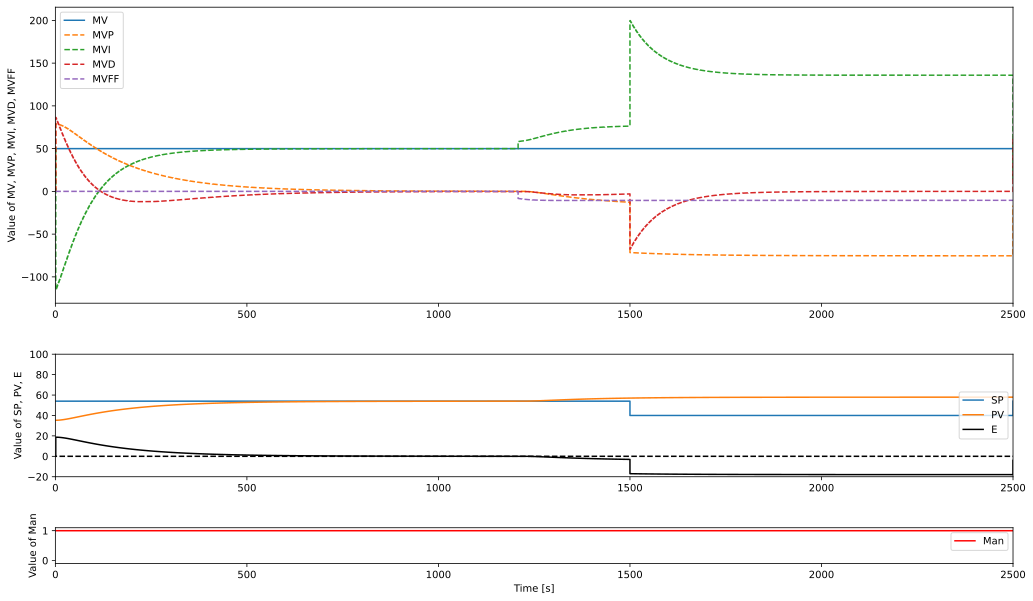

In [25]:

plt.figure(figsize = (15,9))


plt.subplot(7,1,(1,4))
plt.step(t,MV, label='MV',where='post' )
plt.step(t,MVP, label='MVP',where='post', linestyle='dashed' )
plt.step(t,MVI,label='MVI',where='post', linestyle='dashed')
plt.step(t,MVD,label='MVD',where='post', linestyle='dashed')
plt.step(t,MVFF,label='MVFF',where='post', linestyle='dashed')
# plt.step(t,MVDelay,'b-',linewidth=0.5,label='MV plus delay',where='post')
plt.ylabel('Value of MV, MVP, MVI, MVD, MVFF')
plt.legend(loc='best')
plt.xlim([0, TSim])



plt.subplot(7,1,(5,6))
plt.step(t,SP, label='SP',where='post')
plt.step(t,PV, label='PV',where='post')

plt.step(t,E,'black',label='E',where='post')
plt.hlines(0, -10, 10000, colors="black", linestyles='dashed')

plt.ylim((-20,100))
# plt.step(t,MVDelay,'b-',linewidth=0.5,label='MV plus delay',where='post')
plt.ylabel('Value of SP, PV, E')
plt.legend(loc='right')
plt.xlim([0, TSim])



plt.subplot(7,1,7)
plt.ylim((-0.1,1.1))
plt.step(t,Man,'r-',label='Man',where='post')
# plt.step(t,PV_TRAP,'springgreen',label='First order response plus delay (TRAP)',where='post')
plt.ylabel('Value of Man')
plt.xlabel('Time [s]')
plt.legend(loc='best')
plt.xlim([0, TSim])    



plt.tight_layout(pad=3.0) # 'pad' defines the space around the figure edges
plt.show()
